# Day 1 - Hands-On Lab: K-Means Clustering

In this lab, I will apply K-Means clustering to a numeric dataset.

The goal is to discover natural groups in the data without giving the model any target labels.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#### Step 1: Load and scale a provided dataset (numeric features only) with StandardScale

For this lab, I am using the Iris dataset.

The dataset contains four numeric features describing flowers:

- Sepal length
- Sepal width
- Petal length
- Petal width

Normally, the Iris dataset also contains the flower species as a target.

However, because this is an unsupervised learning task, I will not give those labels to K-Means.

The model will only receive the feature matrix `X` and will try to discover groups by itself.

In [3]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
df.shape

(150, 4)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [6]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Checking the Data

Before applying clustering, I want to make sure the dataset is suitable for K-Means.

K-Means works with numeric features because it calculates distances between points and cluster centroids.

The Iris dataset already contains only numeric features, so no categorical encoding is required.

I will also check whether there are any missing values.

In [7]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

## Scale the Features

Scaling is especially important for K-Means because the algorithm uses distance.

If one feature has much larger values than another feature, it can have too much influence on the clustering result.

I will use `StandardScaler` so that all features are placed on a similar scale.

After scaling, each feature will approximately have:

- Mean = 0
- Standard deviation = 1

In [8]:
X = df.copy()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [9]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=df.columns
)

X_scaled_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


#### Step 2: Run K-Means for k from 1 to 10 and plot inertia to find the elbow.
K-Means requires the number of clusters `k` before training.

Since I do not know the best number of clusters yet, I will train several K-Means models using values of `k` from 1 to 10.

For each model, I will record its **inertia**.

Inertia measures the total squared distance between each point and the centroid of its assigned cluster.

A smaller inertia means the points are closer to their cluster centers.

However, inertia always decreases when `k` increases.

Because of this, I am not simply looking for the smallest inertia. Instead, I am looking for the point where increasing `k` stops giving a large improvement.

This point is called the **elbow**.

In [10]:
inertias = []

k_values = range(1, 11)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_scaled)
    
    inertias.append(model.inertia_)

In [11]:
inertia_results = pd.DataFrame({
    "k": k_values,
    "Inertia": inertias
})

inertia_results

,k,Inertia
0,1,600.000000
1,2,222.361705
2,3,139.820496
3,4,114.092547
4,5,90.927514
5,6,81.544391
6,7,72.631144
7,8,62.540606
8,9,55.119493
9,10,47.391035


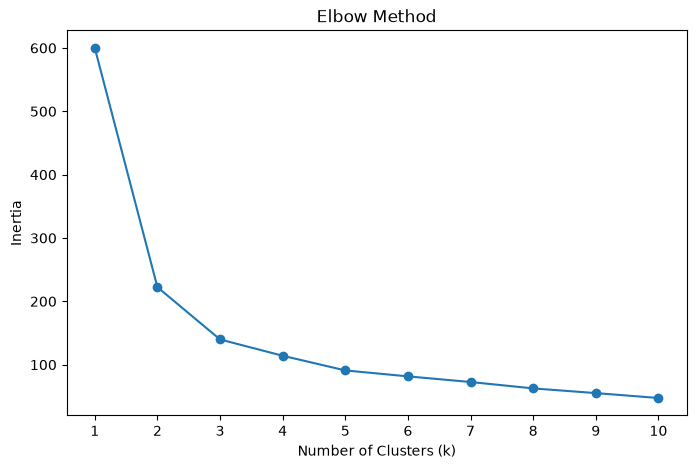

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(k_values)

plt.show()

## Elbow Method Interpretation

From the inertia results, there is a very large decrease from `k = 1` to `k = 2`, where inertia drops from about **600** to **222.36**.

There is another noticeable improvement from `k = 2` to `k = 3`, where inertia decreases to about **139.82**.

After `k = 3`, the improvements become smaller and more gradual.

Based on the elbow plot, both `k = 2` and `k = 3` appear to be reasonable candidates.

Because the elbow is not completely obvious, I will compare these two values using the silhouette score.

#### Step 3: Compute the silhouette score for the top two candidate k values and pick the best.

The silhouette score measures how well the data points fit inside their assigned clusters.

It compares two things:

- How close a point is to other points in its own cluster.
- How far that point is from the nearest different cluster.

The score ranges approximately from `-1` to `1`.

A score close to:

- **1** means the clusters are well separated.
- **0** means the clusters overlap.
- **-1** can mean some points may have been assigned to the wrong cluster.

Unlike inertia, a **higher silhouette score is better**.

I will compare `k = 2` and `k = 3`.

In [18]:
candidate_k = [2, 3]

silhouette_results = {}

for k in candidate_k:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_scaled)
    
    score = silhouette_score(
        X_scaled,
        labels
    )
    
    silhouette_results[k] = score

In [19]:
silhouette_df = pd.DataFrame({
    "k": silhouette_results.keys(),
    "Silhouette Score": silhouette_results.values()
})

silhouette_df

,k,Silhouette Score
0,2,0.581750
1,3,0.459948


## Silhouette Score Interpretation

I compared the two main candidate values:

- `k = 2` → Silhouette Score = **0.581750**
- `k = 3` → Silhouette Score = **0.459948**

Since a higher silhouette score indicates better-separated and more compact clusters, `k = 2` gives the better result.

Therefore, I selected:

**k = 2**

The silhouette score of approximately **0.58** suggests that the two clusters are reasonably well separated.

In [20]:
best_k = max(
    silhouette_results,
    key=silhouette_results.get
)

best_k

2

In [21]:
print("Selected number of clusters:", best_k)
print("Silhouette score:", silhouette_results[best_k])

Selected number of clusters: 2
Silhouette score: 0.5817500491982808


## Choosing the Final Number of Clusters

The final selected number of clusters is:

**k = 2**

This value was selected because it had the highest silhouette score among the candidate values.

Although `k = 3` also appeared reasonable from the elbow method, its silhouette score was lower.

This shows why using both the elbow method and silhouette score is useful instead of depending only on the inertia graph.

#### Step 4: Fit final K-Means with the chosen k, and visualize the clusters on a 2D scatter plot.


Now that I have selected the number of clusters, I can train the final K-Means model.

`fit_predict()` performs two operations:

1. It trains K-Means on the data.
2. It returns the cluster assigned to every data point.

The cluster numbers themselves do not have a natural meaning.

For example, `Cluster 0` is not better or worse than `Cluster 1`.

They are simply identifiers created by the algorithm.

In [22]:
final_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = final_model.fit_predict(X_scaled)

In [23]:
df_clustered = df.copy()

df_clustered["Cluster"] = clusters

df_clustered.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


In [24]:
df_clustered["Cluster"].value_counts().sort_index()

Cluster
0    100
1     50
Name: count, dtype: int64

## Cluster Sizes

After fitting the final K-Means model, the dataset was divided into two clusters:

- **Cluster 0:** 100 flowers
- **Cluster 1:** 50 flowers

The clusters are not equal in size.

Cluster 1 contains a smaller and more distinct group, while Cluster 0 contains the remaining larger group of flowers.

This difference in cluster sizes is completely valid because K-Means does not require every cluster to contain the same number of observations.

## Cluster Centroids

Each K-Means cluster has a centroid.

The centroid represents the average position of the points belonging to that cluster.

Because I trained K-Means using scaled data, the original centroids are currently expressed in standardized units.

To make them easier to understand, I will transform the centroids back to the original feature scale.

In [26]:
scaled_centroids = final_model.cluster_centers_

original_centroids = scaler.inverse_transform(
    scaled_centroids
)

centroids_df = pd.DataFrame(
    original_centroids,
    columns=df.columns
)

centroids_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,6.262,2.872,4.906,1.676
1,5.006,3.428,1.462,0.246


# Visualize the Clusters

The dataset contains four features, which means every flower is technically represented in four-dimensional space.

It is difficult to directly visualize four dimensions.

For a simple visual interpretation, I will plot:

- Petal length
- Petal width

These two features are useful because they show clear differences between different groups of flowers.

The colors represent the clusters discovered by K-Means.

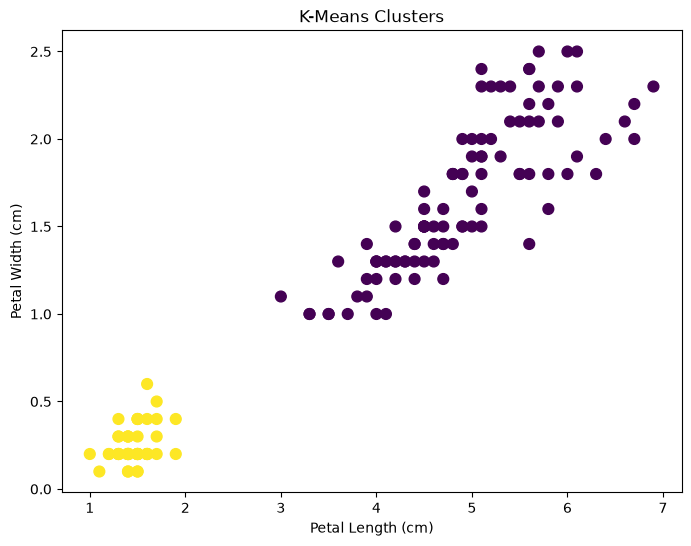

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["petal length (cm)"],
    df["petal width (cm)"],
    c=clusters,
    s=60
)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("K-Means Clusters")

plt.show()

## Add the Centroids to the Visualization

To make the clustering result easier to understand, I will also display the centroid of each cluster.

The centroid represents the center of the cluster according to K-Means.

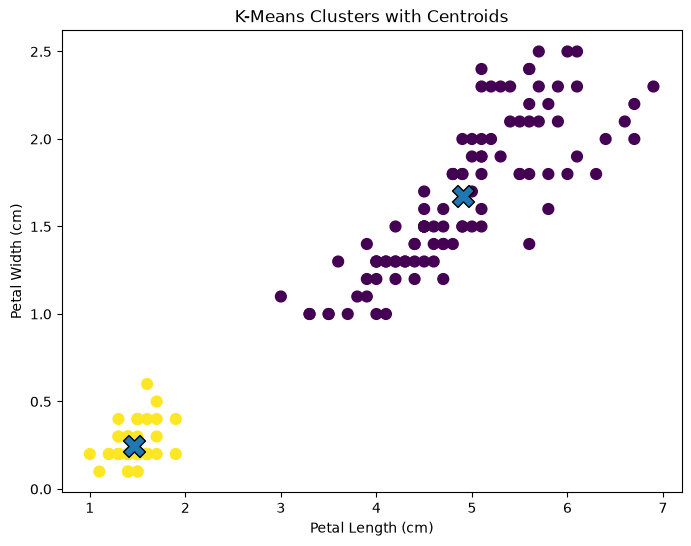

In [28]:
petal_length_index = df.columns.get_loc("petal length (cm)")
petal_width_index = df.columns.get_loc("petal width (cm)")

plt.figure(figsize=(8, 6))

plt.scatter(
    df["petal length (cm)"],
    df["petal width (cm)"],
    c=clusters,
    s=60
)

plt.scatter(
    original_centroids[:, petal_length_index],
    original_centroids[:, petal_width_index],
    marker="X",
    s=250,
    edgecolors="black"
)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("K-Means Clusters with Centroids")

plt.show()

####  Step 5: Interpret what each cluster represents in a Markdown cell.
To understand what each cluster represents, I can compare the average feature values of the observations assigned to each cluster.

This is important because K-Means only gives cluster numbers.

It does not explain what those clusters mean.

The interpretation must come from examining the characteristics of the points inside each cluster.

In [29]:
cluster_summary = df_clustered.groupby("Cluster").mean()

cluster_summary

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
Cluster,,,,
0,6.262,2.872,4.906,1.676
1,5.006,3.428,1.462,0.246


## Cluster Interpretation

The cluster averages show a clear difference between the two groups.

### Cluster 0

Cluster 0 contains **100 flowers**.

Its average measurements are approximately:

- Sepal length: **6.26 cm**
- Sepal width: **2.87 cm**
- Petal length: **4.91 cm**
- Petal width: **1.68 cm**

This cluster represents flowers with **larger petals and generally larger overall measurements**.

The petal length and petal width are especially much larger than those in Cluster 1.

### Cluster 1

Cluster 1 contains **50 flowers**.

Its average measurements are approximately:

- Sepal length: **5.01 cm**
- Sepal width: **3.43 cm**
- Petal length: **1.46 cm**
- Petal width: **0.25 cm**

This cluster represents flowers with **very small and narrow petals**.

Interestingly, although these flowers have smaller petals and shorter sepals, their average sepal width is larger than the flowers in Cluster 0.

### Overall Interpretation

The strongest difference between the two clusters comes from the **petal measurements**.

Cluster 1 contains flowers with very small petals, while Cluster 0 contains flowers with much larger petals.

This means that K-Means was able to discover a meaningful natural separation in the dataset without being given any species labels.

This is a good example of unsupervised learning because the model found structure using only the feature values.

# Final Results

In this lab, I applied K-Means clustering to the Iris dataset without using the real flower species as labels.

First, I checked the dataset and confirmed that it contained:

- **150 observations**
- **4 numeric features**
- **No missing values**

I then scaled all features using `StandardScaler` because K-Means depends on distance and can be affected by differences in feature scales.

To choose the number of clusters, I used the elbow method for values of `k` from 1 to 10.

The elbow graph suggested that `k = 2` and `k = 3` were strong candidates.

I then compared these values using the silhouette score:

- `k = 2`: **0.581750**
- `k = 3`: **0.459948**

Since `k = 2` had the higher silhouette score, I selected it as the final number of clusters.

The final model created:

- **Cluster 0:** 100 flowers
- **Cluster 1:** 50 flowers

Cluster 0 contained flowers with larger petals, with an average petal length of about **4.91 cm** and petal width of about **1.68 cm**.

Cluster 1 contained flowers with much smaller petals, with an average petal length of about **1.46 cm** and petal width of about **0.25 cm**.

The most important thing I learned from this lab is that K-Means can discover meaningful groups without knowing the correct labels.

Unlike classification, where the model learns from a target `y`, clustering works only with `X` and tries to find hidden structure based on similarities between observations.